# **Fundamentos de Aprendizaje por Refuerzo**
## **Q-Learning Algorithm**


In [5]:
import gymnasium

In [4]:
import pygame

In [6]:
import imageio

### **Liberías**

In [7]:
import numpy as np
import gymnasium as gym
import random
from collections import deque
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image

## **Visualización gráfica del entorno**

Entorno obtenido de: https://gymnasium.farama.org/environments/toy_text/cliff_walking/

## **Funcionamiento del entorno**

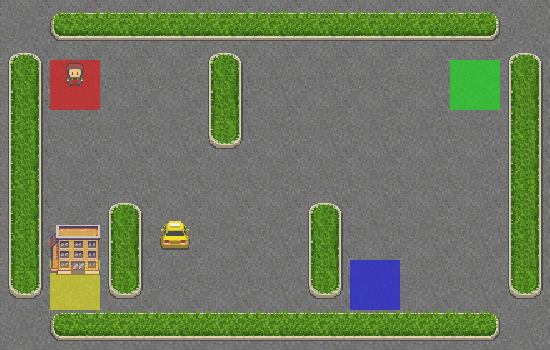

In [8]:
env = gym.make('Taxi-v4', render_mode="rgb_array")
state, _ = env.reset()
done = False
frames = []
for i in range(20):
    action = random.choice([0,1,2,3])  # Elegir una acción random
    next_state, reward ,done, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
env.close()
imageio.mimsave('taxi_env.gif', frames, fps=3)
Image(filename='taxi_env.gif')

## **Crear y observar el ambiente (estados y acciones)**

In [9]:
env = gym.make('Taxi-v4', render_mode="rgb_array")
num_states = env.observation_space.n
num_actions = env.action_space.n

print(f"Número de estados: {num_states}")
print(f"Número de acciones: {num_actions}")

Número de estados: 500
Número de acciones: 6


## **Q-Learning Implementation**

<style>
.MathJax {
    color: #FFFFFF !important;
}
</style>

**Epsilon-Greedy Policy**


\begin{align}
a_t =
        \begin{cases}
        \text{random action} & \quad\text{with probability  }\epsilon \\
        \displaystyle\text{arg}\max_a{Q(s_t,:)}&\quad\text{with probability  }   1-\epsilon
        \end{cases}
\end{align}


**Q-learning Algorithm**


<img src="https://raw.githubusercontent.com/cdavid2804/test-1/main/Q_learning_Algorithm.png" alt="QL_Algorithm" width="700"/>

#Entrenamiento

In [13]:
alpha = 0.7 # Tasa de aprendizaje
gamma = 0.995 # Factor de descuento
epsilon = 0.1 # epsilon
num_episodes = 1000 # Número de episodios
episodes_reward = deque(maxlen=num_episodes)

Q = np.zeros((num_states, num_actions))
np.random.seed(0)

# Estrategia para que el agente elija las acciones
def epsilon_greedy(state, epsilon):
  if np.random.rand() < epsilon:
    action = np.random.randint(num_actions)
  else:
    action = np.argmax(Q[state,:])
  return action

# Entrenamiento
for episode in range(num_episodes):
  state, _ = env.reset()
  done = False
  total_reward = 0
  steps = 0
  while not done:
    action = epsilon_greedy(state, epsilon)
    next_state, reward, done, _, _ = env.step(action)
    Q[state, action] = Q[state, action] + alpha * (reward + gamma * np.max(Q[next_state,:])-Q[state,action])
    total_reward += reward
    state = next_state
    steps += 1
  episodes_reward.append([episode, total_reward])

  print(f"Episode: {episode} | Total Reward: {total_reward} | Steps: {steps}")
  env.close()


Episode: 0 | Total Reward: -2557 | Steps: 1111
Episode: 1 | Total Reward: -618 | Steps: 459
Episode: 2 | Total Reward: -1303 | Steps: 514
Episode: 3 | Total Reward: -2360 | Steps: 1013
Episode: 4 | Total Reward: -1251 | Steps: 660
Episode: 5 | Total Reward: -3448 | Steps: 1516
Episode: 6 | Total Reward: -297 | Steps: 246
Episode: 7 | Total Reward: -62 | Steps: 83
Episode: 8 | Total Reward: -1537 | Steps: 820
Episode: 9 | Total Reward: -2078 | Steps: 920
Episode: 10 | Total Reward: -296 | Steps: 236
Episode: 11 | Total Reward: -233 | Steps: 209
Episode: 12 | Total Reward: -211 | Steps: 169
Episode: 13 | Total Reward: -164 | Steps: 158
Episode: 14 | Total Reward: -256 | Steps: 214
Episode: 15 | Total Reward: -256 | Steps: 214
Episode: 16 | Total Reward: -132 | Steps: 108
Episode: 17 | Total Reward: -176 | Steps: 161
Episode: 18 | Total Reward: -159 | Steps: 135
Episode: 19 | Total Reward: -215 | Steps: 173
Episode: 20 | Total Reward: -568 | Steps: 436
Episode: 21 | Total Reward: -2 | Ste

## **Gráfica de la recompensa total acumulada y recompensa promedio**

In [15]:
episodeReward = np.array(episode_reward)
episodes = episodeReward[:,0]
# Total rewards
rewards = episodeReward[:,1]
# Mean rewards
meanRewards = np.zeros(len(episodes))

for i in range(len(episodes)):
    if i == 0:
        meanRewards[0] = rewards[0]
    else:
        meanRewards[i] = np.mean(rewards[:i])
plt.figure(figsize=(7, 6))
plt.plot(episodes, rewards, label=r"Total reward, $\alpha=$"+str(alpha), linewidth=4, color='purple')
plt.plot(episodes, meanRewards, label=r"Mean reward, $\alpha$="+str(alpha), linewidth=4, color='orange')
plt.xlabel("Episode number")
plt.ylabel("Episode reward")
plt.xlim(0, num_episodes)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid()
plt.legend()
plt.show()

NameError: name 'episode_reward' is not defined

## **Probar la política entrenada**